# Extract polygons of UK cities

When extracting the polygons for european cities with >100k citizens from OpenStreetMap (see notebook `check_polygons.ipynb`), some polygons were found to be too big. 

This was the case for 7 UK cities.


## Setup

In [1]:
import requests
from shapely import Polygon, MultiPolygon
from shapely.geometry import shape
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as cx
import textwrap # for long titles
import os
from shapely.ops import unary_union
import pandas as pd
import osmnx as ox

## Import UK geografic regions (Scotland)

The data is from the [National Data Library](https://www.data.gov.uk/dataset/1d488abe-f8e8-4ff0-b7b7-9c976b9bce64/community-council-boundaries-scotland), and downloadable from [here](https://data.spatialhub.scot/dataset/community_council_boundaries-is)

In [ ]:
path = "../cities/development/Community_Council_Boundaries_-_Scotland/pub_commcnc.shp"
layers = gpd.list_layers(path)
layers

,name,geometry_type
0,pub_commcnc,Polygon


In [3]:
scotland = gpd.read_file(path)
scotland

,la_s_code,local_auth,cc_name,active,population,url,sh_date_up,sh_src,sh_src_id,geometry
0,S12000033,Aberdeen City,Ashgrove and Stockethill,NaN,NaN,https://www.aberdeencity.gov.uk/services/counc...,2026-04-09,a538c771-c7e8-4590-b19a-e7b11c954fde,263.0,"POLYGON ((391682.38 808215.1, 391682.48 808215..."
1,S12000033,Aberdeen City,Ashley and Broomhill,No,7502,https://www.aberdeencity.gov.uk/services/counc...,2026-04-09,a538c771-c7e8-4590-b19a-e7b11c954fde,248.0,"POLYGON ((392543.54 804177.19, 392542.65 80417..."
2,S12000033,Aberdeen City,Braeside and Mannofield,Yes,6081,https://www.aberdeencity.gov.uk/services/counc...,2026-04-09,a538c771-c7e8-4590-b19a-e7b11c954fde,247.0,"POLYGON ((390253.15 804354.1, 390262.91 804355..."
3,S12000033,Aberdeen City,Bridge of Don,Yes,18371,https://www.aberdeencity.gov.uk/services/counc...,2026-04-09,a538c771-c7e8-4590-b19a-e7b11c954fde,268.0,"POLYGON ((390919.92 813501.69, 390924.97 81349..."
4,S12000033,Aberdeen City,Bucksburn and Newhills,Yes,9032,https://www.aberdeencity.gov.uk/services/counc...,2026-04-09,a538c771-c7e8-4590-b19a-e7b11c954fde,267.0,"POLYGON ((383929.29 809195.67, 383955.94 80920..."
...,...,...,...,...,...,...,...,...,...,...
1358,S12000040,West Lothian,Uphall Station,Yes,1159,https://www.westlothian.gov.uk/communitycouncils,2023-01-30,46abf8a8-f01e-4f46-b87e-f2aca6ebee1c,522.0,"POLYGON ((306504.9 669685.99, 306504.41 669686..."
1359,S12000040,West Lothian,West Calder and Harburn,Yes,3830,https://www.westlothian.gov.uk/communitycouncils,2023-01-30,46abf8a8-f01e-4f46-b87e-f2aca6ebee1c,523.0,"POLYGON ((309774.95 656914.89, 309772.5 656907..."
1360,S12000040,West Lothian,Westfield and Bridgehouse,No,858,https://www.westlothian.gov.uk/communitycouncils,2023-01-30,46abf8a8-f01e-4f46-b87e-f2aca6ebee1c,524.0,"POLYGON ((291293.31 669574.68, 291292.71 66957..."
1361,S12000040,West Lothian,Whitburn,Yes,13037,https://www.westlothian.gov.uk/communitycouncils,2023-01-30,46abf8a8-f01e-4f46-b87e-f2aca6ebee1c,525.0,"POLYGON ((296012.53 663684.52, 296012.5 663685..."


## Import "unaccepted" UK cities

In [5]:
european_100000pop = pd.read_excel(
    '../cities/development/european_100000pop_comments.xlsx',
    sheet_name = 'Comments',
    usecols = "A:C,E:F,H"
    ).query("accepted == 0 & country_en == 'United Kingdom'").drop(columns = ['accepted']).sort_values(by=['name_en', 'country_en']).reset_index(drop=True).set_index('name_en')
european_100000pop

,country_en,nominatim_query,alpha-2,population
name_en,,,,
Aberdeen,United Kingdom,Aberdeen,GB,207932
Bolton,United Kingdom,Bolton,GB,194189
Bradford,United Kingdom,"Bradford, West Yorkshire",GB,349561
Cardiff,United Kingdom,"Cardiff, Wales",GB,335145
Edinburgh,United Kingdom,Edinburgh,GB,482005
Leeds,United Kingdom,Leeds,GB,474632


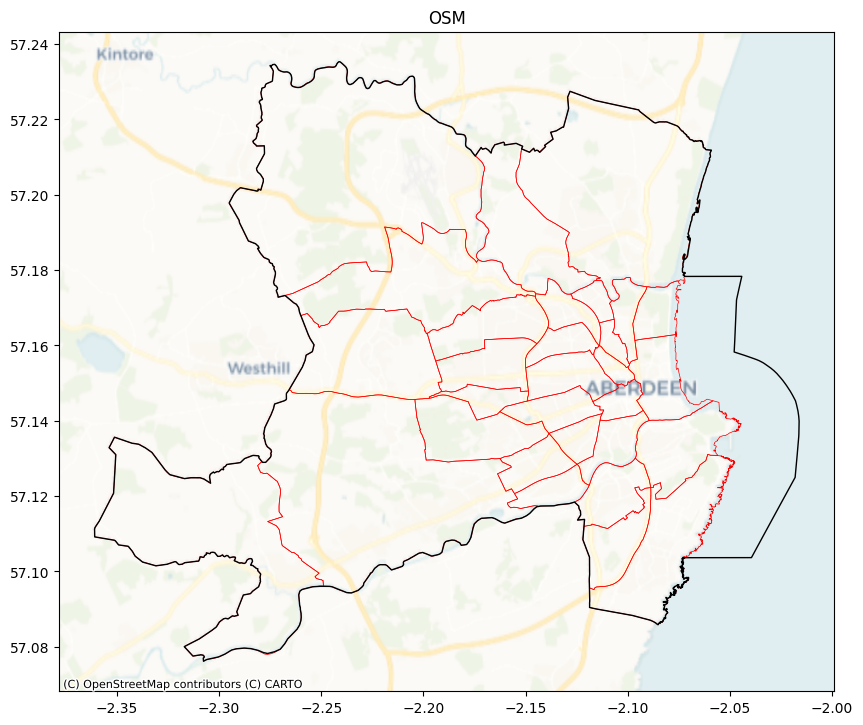

In [8]:
city = "Aberdeen"

osm = ox.geocoder.geocode_to_gdf(european_100000pop.loc[city,'nominatim_query'])
osm_poly = osm.geometry.iloc[0]
tags = {
    'boundary': 'administrative',
    'admin_level': '8'  
}
subdivisions = ox.features_from_polygon(osm_poly, tags=tags).query("admin_level == '8'")
clipped_subdivisions = gpd.clip(subdivisions, osm_poly)
clipped_subdivisions = clipped_subdivisions[
    clipped_subdivisions.geometry.type.isin(['Polygon', 'MultiPolygon'])
]

councils = scotland.query("local_auth == 'Aberdeen City'").to_crs(osm.crs)

fig, ax = plt.subplots(
    figsize=(10,10),
    ncols = 1,
    nrows = 1
)

#ax = axes.flatten()

# if not clipped_subdivisions.empty:
#     clipped_subdivisions.plot(
#         ax = ax,
#         facecolor="none",       
#         edgecolor="red",        
#         linestyle="-",         
#         linewidth=0.5
#     )
councils.plot(
    ax = ax,
    facecolor="none",       
    edgecolor="red",        
    linestyle="-",         
    linewidth=0.5
)  
osm.plot(
    ax = ax,
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=1
)
ax.set_title("OSM")
cx.add_basemap(ax, crs=osm.crs, source=cx.providers.CartoDB.Voyager, alpha = 0.7)


plt.show()

# Conclusion

The units smaller than municipalities don't correspond to the ones in the Google Maps, so they are not considered.